In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns



In [2]:
# Lendo o dataset
# Foi utilizado engine="odf" para permitir a leitura de arquivos no formato .ods
# As nove primeiras linhas da planilha contêm informações descritivas e não fazem parte da tabela de dados. 
# Por isso, foi utilizado skiprows=9 para iniciar a leitura diretamente dos dados relevantes

df_bruto = pd.read_excel(r"C:\Users\gabri\OneDrive\Área de Trabalho\Trabalho python 25-05\Input\Remuneracao_docentes_Municipios_2021.ods", engine="odf", skiprows=9)

In [3]:
# Informações gerais
df_bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 16025 entries, 0 to 16024
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   2021                   16024 non-null  object 
 1   Norte                  16022 non-null  str    
 2   RO                     16022 non-null  str    
 3   1100015                16022 non-null  float64
 4   Alta Floresta D'Oeste  16022 non-null  str    
 5   Municipal              16022 non-null  str    
 6   Total                  16022 non-null  str    
 7   157                    16022 non-null  float64
 8   95.5414                16022 non-null  object 
 9   2226.77                16022 non-null  object 
 10  4020.86                16022 non-null  object 
 11  3390.503               16022 non-null  object 
 12  4347.53                16022 non-null  object 
 13  1056.048               16022 non-null  object 
 14  31.94035               16022 non-null  object 
 15  4246.043     

In [4]:
# Quantidade de linhas e colunas
df_bruto.shape

(16025, 16)

In [5]:
# A análise será feita somente dos municípios do Ceará
df = df_bruto.iloc[2635:3185]


In [6]:
df

,2021,Norte,RO,1100015,Alta Floresta D'Oeste,Municipal,Total,157,95.5414,2226.77,4020.86,3390.503,4347.53,1056.048,31.94035,4246.043
2635,2021,Nordeste,CE,2300101.0,Abaiara,Municipal,Total,125.0,100,2006.47,2306.69,2652.8,2703.47,1194.691,21.9005,4845.187
2636,2021,Nordeste,CE,2300101.0,Abaiara,Municipal,Com Superior,92.0,100,2063.52,2678.19,2995.948,4128.15,1219.562,22.32344,5368.256
2637,2021,Nordeste,CE,2300101.0,Abaiara,Municipal,Sem Superior,33.0,100,1462.384,1798,1773.278,2063.52,444.9973,20.81647,3407.451
2638,2021,Nordeste,CE,2300150.0,Acarape,Municipal,Total,152.0,100,1053.33,1053.33,1575.938,1100,1400.535,24.77468,2544.433
2639,2021,Nordeste,CE,2300150.0,Acarape,Municipal,Com Superior,141.0,100,1053.33,1053.33,1561.843,1100,1402.101,24.64732,2534.706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3180,2021,Nordeste,CE,2314003.0,Várzea Alegre,Municipal,Com Superior,356.0,97.75281,1832.45,1999.31,1982.266,2051.79,442.9552,21.05725,3765.48
3181,2021,Nordeste,CE,2314003.0,Várzea Alegre,Municipal,Sem Superior,45.0,100,1467.17,1541.915,1672.357,1999.31,292.8426,20.3384,3289.063
3182,2021,Nordeste,CE,2314102.0,Viçosa do Ceará,Municipal,Total,641.0,99.84399,1623.48,1735.43,2010.573,2099.73,565.0645,20,4021.146
3183,2021,Nordeste,CE,2314102.0,Viçosa do Ceará,Municipal,Com Superior,607.0,99.83526,1623.48,1743.74,2014.818,2099.73,566.3522,20,4029.637


In [7]:
# Quantidade de linhas e colunas atualizadas
df.shape

(550, 16)

In [8]:
# Listando as colunas
df.columns

Index([                   2021,                 'Norte',
                          'RO',                 1100015,
       'Alta Floresta D'Oeste',             'Municipal',
                       'Total',                     157,
                       95.5414,                 2226.77,
                       4020.86,                3390.503,
                       4347.53,                1056.048,
                      31.94035,                4246.043],
      dtype='object')

In [9]:
#Renomeção das colunas de acordo com a tabela original

df.columns = [
        "Ano",
        "Região",
        "UF",
        "Código do município",
        "Nome do município",
        "Dependência administrativa",
        "Escolaridade do docente",
        "Dados gerais Número de docentes",
        "Dados gerais porcentagem de docentes localizados",
        "Remuneração 1º quartil",
        "Remuneração Mediana",
        "Remuneração Média",
        "Remuneração 3º quartil",
        "Remuneração Desvio padrão",
        "Carga horária semanal",
        "Remuneração média pra 40h"
    ]

In [10]:
# Após o filtro dos dados, foi realizado o reset do índice para deixar o DataFrame mais organizado
df.reset_index(drop=True, inplace=True)

In [11]:
df

,Ano,Região,UF,Código do município,Nome do município,Dependência administrativa,Escolaridade do docente,Dados gerais Número de docentes,Dados gerais porcentagem de docentes localizados,Remuneração 1º quartil,Remuneração Mediana,Remuneração Média,Remuneração 3º quartil,Remuneração Desvio padrão,Carga horária semanal,Remuneração média pra 40h
0,2021,Nordeste,CE,2300101.0,Abaiara,Municipal,Total,125.0,100,2006.47,2306.69,2652.8,2703.47,1194.691,21.9005,4845.187
1,2021,Nordeste,CE,2300101.0,Abaiara,Municipal,Com Superior,92.0,100,2063.52,2678.19,2995.948,4128.15,1219.562,22.32344,5368.256
2,2021,Nordeste,CE,2300101.0,Abaiara,Municipal,Sem Superior,33.0,100,1462.384,1798,1773.278,2063.52,444.9973,20.81647,3407.451
3,2021,Nordeste,CE,2300150.0,Acarape,Municipal,Total,152.0,100,1053.33,1053.33,1575.938,1100,1400.535,24.77468,2544.433
4,2021,Nordeste,CE,2300150.0,Acarape,Municipal,Com Superior,141.0,100,1053.33,1053.33,1561.843,1100,1402.101,24.64732,2534.706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,2021,Nordeste,CE,2314003.0,Várzea Alegre,Municipal,Com Superior,356.0,97.75281,1832.45,1999.31,1982.266,2051.79,442.9552,21.05725,3765.48
546,2021,Nordeste,CE,2314003.0,Várzea Alegre,Municipal,Sem Superior,45.0,100,1467.17,1541.915,1672.357,1999.31,292.8426,20.3384,3289.063
547,2021,Nordeste,CE,2314102.0,Viçosa do Ceará,Municipal,Total,641.0,99.84399,1623.48,1735.43,2010.573,2099.73,565.0645,20,4021.146
548,2021,Nordeste,CE,2314102.0,Viçosa do Ceará,Municipal,Com Superior,607.0,99.83526,1623.48,1743.74,2014.818,2099.73,566.3522,20,4029.637


In [12]:
# Criação de uma variável com as colunas númericas para uma melhor análise

colunas_numericas = [
    "Dados gerais Número de docentes",
    "Dados gerais porcentagem de docentes localizados",
    "Remuneração 1º quartil",
    "Remuneração Mediana",
    "Remuneração Média",
    "Remuneração 3º quartil",
    "Remuneração Desvio padrão",
    "Carga horária semanal",
    "Remuneração média pra 40h"
]

In [13]:
# Foi realizado a conversão de todas as colunas númericas para o formato de número e transformando valores inválidos(NaN) em nulos 
# e em seguida esses valores nulos foram substituidos por zero permitindo assim a realização de cálculos

df[colunas_numericas] = df[colunas_numericas].apply(pd.to_numeric, errors="coerce")
df[colunas_numericas] = df[colunas_numericas].fillna(0)

In [14]:
#Qual a quantidade de professores existentes em 2021?

df[df["Escolaridade do docente"] !="Total"]["Dados gerais Número de docentes"].sum()

np.float64(65320.0)

In [ ]:
# Qual o total de remuneração dos professores em 2021?
# Os dados foram filtrados para excluir a categoria “Total” e registros sem informação de remuneração. 
# Após esse tratamento, foi calculada a soma da remuneração média dos docentes com base na jornada de 40 horas semanais

df[
    (df["Escolaridade do docente"] != "Total") &
    (df["Remuneração média pra 40h"])
]["Remuneração média pra 40h"].sum()

np.float64(1239268.7681)

In [16]:
# Qual a média de horas que os professores trabalharam semanalmente em 2021?

# O resultado sugere diferentes regimes de trabalho, com jornadas possivelmente distribuídas entre cargas horárias parciais e integrais
# Resultando em uma média inferior à jornada padrão de 40h semanais

df["Carga horária semanal"].mean().round(2)


np.float64(26.38)

In [18]:
#Qual cidade tem menos professores localizados
df_total = df[df["Escolaridade do docente"] == "Total"]

menor = df_total.loc[
    df_total["Dados gerais porcentagem de docentes localizados"].idxmin()
]

print(menor["Nome do município"])
print(menor["Dados gerais porcentagem de docentes localizados"])

Chorozinho
0.0


In [19]:
#Qual cidade tem mais professores localizados?
df_total = df[df["Escolaridade do docente"] == "Total"]

maior = df_total.loc[
    df_total["Dados gerais porcentagem de docentes localizados"].idxmax()
]

print(maior["Nome do município"])
print(maior["Dados gerais porcentagem de docentes localizados"])

Abaiara
100.0


In [20]:
# Qual cidade tem mais professores?
df_total = df[df["Escolaridade do docente"] == "Total"]

maior = df_total.loc[
    df_total["Dados gerais Número de docentes"].idxmax()
]

print(maior["Nome do município"])
print(maior["Dados gerais Número de docentes"])


Fortaleza
8522.0


In [21]:
#Qual cidade tem menos professores?
df_total = df[df["Escolaridade do docente"] == "Total"]

menor = df_total.loc[
    df_total["Dados gerais Número de docentes"].idxmin()
]

print(menor["Nome do município"])
print(menor["Dados gerais Número de docentes"])

Baixio
67.0


In [ ]:
# A análise agrupou os registros por município utilizando a função groupby() e calculou a carga horária semanal média dos docentes usando a função mean(). 
# Os municípios foram ordenados da maior para a menor valor e os 10 municípios com maiores médias foram selecionados pra análise

top10 = (
    df.groupby('Nome do município')['Carga horária semanal']
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top10

,Nome do município,Carga horária semanal
0,Mucambo,44.000000
1,Saboeiro,43.991920
2,Assaré,43.940277
3,Mauriti,43.069237
4,Milagres,41.412800
5,Brejo Santo,40.254137
6,Independência,40.053717
7,Limoeiro do Norte,39.505563
8,Pacajus,39.503183
9,Horizonte,39.391573


#Ranking dos 8 municípios com maior remuneração dos professores  
# Foi construído um ranking dos 8 municípios com maior remuneração média para jornada de 40 horas semanais. Os dados foram filtrados para considerar apenas registros consolidados (“Total”), removendo valores ausentes. Em seguida, os municípios foram ordenados de forma decrescente e apresentados por meio de um gráfico de barras horizontal para facilitar a comparação entre os maiores valores.

In [26]:
df_total = df[df["Escolaridade do docente"] == "Total"]

In [27]:
top8 = (
    df_total[["Nome do município", "Remuneração média pra 40h"]]
    .dropna()
    .sort_values("Remuneração média pra 40h", ascending=False)
    .head(8)
)

C:\Users\gabri\AppData\Local\Temp\ipykernel_21380\3755855304.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


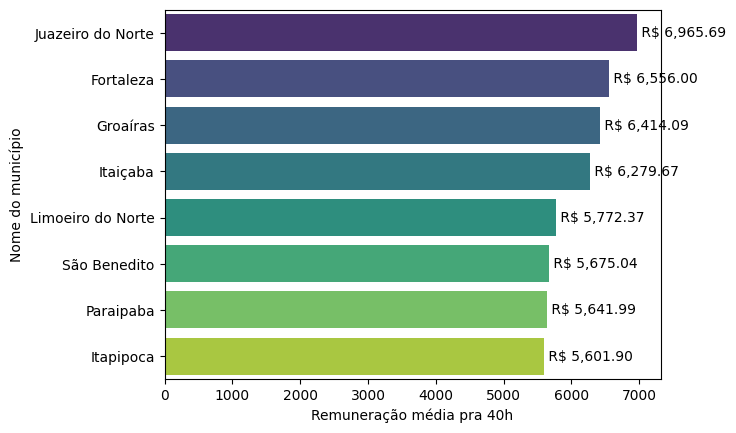

In [30]:
ax = sns.barplot(
    data=top8,
    x="Remuneração média pra 40h",
    y="Nome do município",
    palette="viridis"
)

for i, v in enumerate(top8["Remuneração média pra 40h"]):
    ax.text(v, i, f" R$ {v:,.2f}", va='center')

plt.show()